# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [18]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [19]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [20]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [21]:
# revisar el número de filas y columnas de cada dataset
print("plans:", plans.shape)
print("users:", users.shape)
print("usage:", usage.shape)

plans: (2, 8)
users: (4000, 8)
usage: (40000, 6)


In [15]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [16]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [17]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [22]:
# cantidad de nulos para users
users_nulls = users.isnull().sum()
print("Cantidad de valores nulos:")
print(users_nulls)

Cantidad de valores nulos:
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64


In [23]:
# cantidad de nulos para usage
users_nulls_ratio = users.isnull().mean() * 100
print("Proporción (%) de valores nulos:")
print(users_nulls_ratio)

Proporción (%) de valores nulos:
user_id        0.000
first_name     0.000
last_name      0.000
age            0.000
city          11.725
reg_date       0.000
plan           0.000
churn_date    88.350
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.


💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
 
- En el dataset users, se identifican valores nulos en dos columnas:
    - city: presenta aproximadamente 11.7% de valores faltantes (469 registros).
    - churn_date: presenta alrededor de 88.35% de valores faltantes (3534 registros).
    - El resto de las columnas no presentan valores ausentes.
  
- Indica qué harías: ¿imputar, eliminar, ignorar?

- city (11.7%)
- Este porcentaje se encuentra en un rango intermedio (entre 5% y 30%), por lo que no conviene eliminar la columna. Dado que la ciudad puede ser relevante para análisis geográficos o segmentación, lo más adecuado sería imputar los valores faltantes, por ejemplo con la ciudad más frecuente (moda) o marcarlos como “Unknown”. También podría investigarse si existe otra variable relacionada que ayude a inferirla.

- churn_date (88.35%)
    - Aunque el porcentaje de nulos es muy alto, en este caso tiene sentido: la mayoría de los clientes probablemente no han cancelado el servicio, por lo que no existe una fecha de churn. Por ello, estos nulos no representan un problema de calidad sino una característica del negocio. Se recomienda mantener la columna y tratar los nulos como “cliente activo”, o crear una variable binaria (churn sí/no) para facilitar el análisis.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [24]:
# explorar columnas numéricas de users
users[['user_id', 'age']].describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` ... Haz doble clic en este bloque y escribe qué ves.
  
    - Tiene 4000 registros, lo que coincide con el tamaño del dataset.
    - Los valores van aproximadamente de 10000 a 13999, lo que sugiere identificadores consecutivos.
    - No hay valores negativos ni fuera de rango.
    - Funciona como identificador único y no presenta valores inválidos ni sentinels.
    - La columna contiene identificadores únicos consecutivos en un rango razonable. No se observan valores negativos ni inconsistencias, por lo que no se detectan valores inválidos o sentinels.
  
- La columna `age` ...

    - El valor mínimo es -999, la edad no puede ser negativa.
    - El resto de valores (25%, 50%, 75%, max) están entre 32 y 79 → rango normal
    - La mayoría de las edades se encuentran dentro de un rango lógico para clientes adultos. Sin embargo, se observa un valor mínimo de -999, lo cual es imposible para una edad y probablemente representa un valor sentinela utilizado para indicar datos faltantes o desconocidos.

In [22]:
# explorar columnas numéricas de usage
users[['user_id', 'age']].describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- Las columnas `id` y `user_id`...Haz doble clic en este bloque y escribe qué ves.
- Las columnas ...
  
La columna user_id ... Haz doble clic en este bloque y escribe qué ves.
- Tiene 4000 registros, lo que coincide con el tamaño del dataset. Los valores van aproximadamente de 10000 a 13999, lo que sugiere identificadores consecutivos. No hay valores negativos ni fuera de rango. Funciona como identificador único y no presenta valores inválidos ni sentinels.
- La columna contiene identificadores únicos consecutivos en un rango razonable. No se observan valores negativos ni inconsistencias, por lo que no se detectan valores inválidos o sentinels.

La columna age ...
- El valor mínimo es -999, la edad no puede ser negativa. El resto de valores (25%, 50%, 75%, max) están entre 32 y 79 → rango normal
- La mayoría de las edades se encuentran dentro de un rango lógico para clientes adultos. Sin embargo, se observa un valor mínimo de -999, lo cual es imposible para una edad y probablemente representa un valor sentinela utilizado para indicar datos faltantes o desconocidos.

In [25]:

# explorar columnas categóricas de users
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']

for col in columnas_user:
    print(f"\nValores únicos en {col}:")
    print(users[col].value_counts(dropna=False))




Valores únicos en city:
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

Valores únicos en plan:
Basico     2595
Premium    1405
Name: plan, dtype: int64


- La columna `city` Contiene los nombres de las ciudades de residencia de los usuarios. Se observan múltiples categorías válidas correspondientes a distintas ubicaciones geográficas. También existen valores faltantes previamente identificados, pero no se detectan etiquetas inválidas o códigos extraños. La variable parece consistente y útil para análisis de segmentación por región.
- La columna `plan` Presenta un número reducido de categorías que corresponden a los planes disponibles para los usuarios. Los valores son consistentes y no muestran errores tipográficos ni categorías inesperadas, lo que indica que la variable está bien estructurada para análisis comparativos entre planes.

In [26]:

# explorar columna categórica de usage
usage['type'].value_counts(dropna=False)


text    22092
call    17908
Name: type, dtype: int64

- La columna `type` Indica el tipo de actividad registrada por el usuario. Los valores observados corresponden a categorías coherentes con el servicio, como llamadas y mensajes. No se detectan valores inválidos, etiquetas extrañas ni inconsistencias, por lo que la variable parece correctamente registrada y útil para analizar el comportamiento de uso según el tipo de servicio.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?

Se identificaron valores inválidos en la columna age del dataset users, específicamente el valor -999, el cual no corresponde a una edad válida y probablemente se utilizó como valor sentinela para representar datos faltantes o desconocidos.
También se detectaron valores problemáticos en la columna city, donde aparecen valores nulos y registros con el símbolo "?", lo que sugiere información de ciudad desconocida o mal registrada.
En las demás columnas analizadas (user_id, plan, type, etc.) no se observaron valores fuera de rango ni categorías inesperadas, por lo que parecen consistentes.


- ¿Qué acción tomarías?
Se recomienda reemplazar el valor -999 en age por NaN para tratarlo como dato faltante y posteriormente imputarlo (por ejemplo, con la mediana) o excluirlo según el análisis.
En la columna city, tanto los valores nulos como el símbolo "?" deberían estandarizarse como valores faltantes (NaN), ya que representan ausencia de información válida.
Las demás variables pueden utilizarse directamente, ya que no presentan inconsistencias evidentes.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [27]:

# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

# Convertir a fecha la columna date de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')


In [29]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [30]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts().sort_index()

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En `reg_date`, ... haz doble clic en este bloque y escribe qué ves.
En reg_date se observan registros en los años 2022, 2023 y 2024, lo cual es consistente con el periodo de análisis. Sin embargo, también aparece el año 2026, que está fuera del rango esperado (datos hasta 2024), por lo que probablemente corresponde a un error de captura o fecha incorrecta.

In [31]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts().sort_index()

2024.0    39950
Name: date, dtype: int64

En `date`, ... haz doble clic en este bloque y escribe qué ves.  
Basaremos el análisis en estas fechas.

En date todos los registros corresponden al año 2024, lo cual es coherente con el periodo de datos disponible. No se observan años fuera de rango ni fechas imposibles.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)

En la columna reg_date se detectan registros con año 2026, que está fuera del rango permitido (los datos solo llegan hasta 2024).
Esto sugiere errores de captura o registros incorrectos.
En la columna date no se observan años fuera de rango, ya que todos pertenecen a 2024.

- ¿Qué harías con ellas?
  Para reg_date, revisar los registros con año 2026.

Dependiendo del contexto, se podría:

- corregir si se conoce la fecha real
- reemplazar por valores nulos (NaT)
- eliminar los registros si no son recuperables
- para date, no se requiere acción ya que los datos son consistentes.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [32]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()

users.loc[users['age'] == -999, 'age'] = age_mediana

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [33]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].value_counts(dropna=False)

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [35]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].dt.year.value_counts(dropna=False).sort_index()

2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [36]:
# Verificación MAR en usage (Missing At Random) para duration
usage.groupby('type')['duration'].apply(lambda x: x.isna().mean())

type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [37]:
# Verificación MAR en usage (Missing At Random) para length
usage.groupby('type')['length'].apply(lambda x: x.isna().mean())

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`
Se observa que los valores nulos en duration y length dependen directamente del tipo de registro (type), por lo que no son aleatorios.
En duration, los registros de tipo call no presentan nulos, mientras que casi todos los registros de tipo text sí los tienen (~ 99.9%).
En length, ocurre lo contrario: los registros de tipo text no presentan nulos, mientras que los de tipo call son mayormente nulos (~ 99.9%).
Esto indica que cada variable solo aplica a un tipo específico de actividad:

- duration → duración de llamadas
- length → longitud de mensajes
  
Por lo tanto, los valores faltantes son estructurales, no errores ni datos perdidos al azar. 

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [5]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
    'is_text': 'sum',
    'is_call': 'sum',
    'duration': 'sum'   # minutos totales de llamadas
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [6]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas',
    'duration': 'cant_minutos_llamada'})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [7]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')

user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [8]:
# Resumen estadístico de las columnas numéricas
user_profile.describe()


,user_id,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,3999.000000,3999.000000,3999.000000
mean,11999.500000,33.739750,5.524381,4.478120,23.317054
std,1154.844867,123.232257,2.358416,2.144238,18.168095
min,10000.000000,-999.000000,0.000000,0.000000,0.000000
25%,10999.750000,32.000000,4.000000,3.000000,11.120000
50%,11999.500000,47.000000,5.000000,4.000000,19.780000
75%,12999.250000,63.000000,7.000000,6.000000,31.415000
max,13999.000000,79.000000,17.000000,15.000000,155.690000


In [9]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100


Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

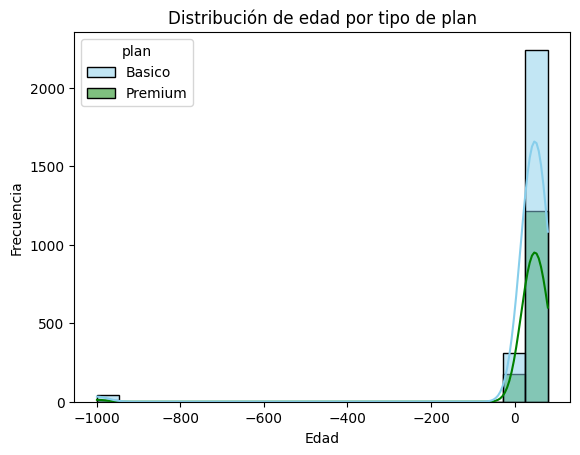

In [10]:

# Histograma para visualizar la edad (age)
sns.histplot(
    data=user_profile,
    x='age',
    hue='plan',
    bins=20,
    palette=['skyblue', 'green'],
    kde=True
)

plt.title('Distribución de edad por tipo de plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()


💡Insights: 
- La distribución de la edad es aproximadamente simétrica, concentrándose principalmente en edades adultas.
- No se observan valores extremos evidentes, lo que indica que la limpieza previa fue efectiva.
- Al comparar por tipo de plan, el plan Premium muestra una ligera mayor concentración en edades más altas, mientras que el plan Básico se distribuye de forma más uniforme.
- No se identifica una diferencia drástica por edad entre planes, pero sí una leve tendencia de usuarios mayores hacia planes Premium.

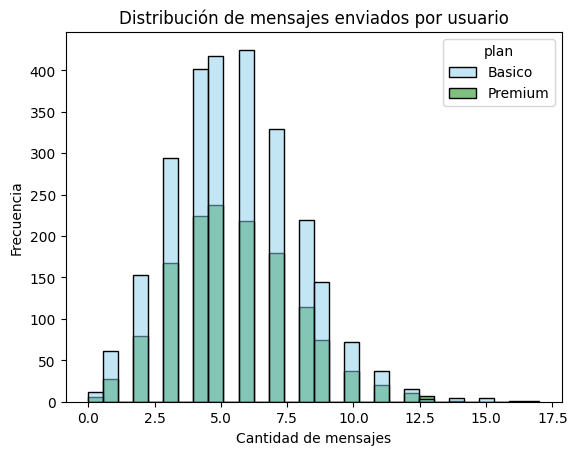

In [14]:
# Histograma para visualizar la cant_mensajes
sns.histplot(
    data=user_profile,
    x='cant_mensajes',
    hue='plan',
    bins=30,
    palette=['skyblue', 'green'],
    kde=False
)

plt.title('Distribución de mensajes enviados por usuario')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- La distribución de la cantidad de mensajes es fuertemente sesgada a la derecha, con la mayoría de los usuarios enviando pocos mensajes.
- Se observa un grupo reducido de usuarios con volúmenes muy altos de mensajes, lo que sugiere la presencia de heavy users.
- Al comparar por tipo de plan, los usuarios del plan Premium tienen mayor presencia en los rangos altos de envío de mensajes.

- Esto indica que los usuarios con mayor uso de mensajería podrían beneficiarse de planes con mayor capacidad o beneficios adicionales.



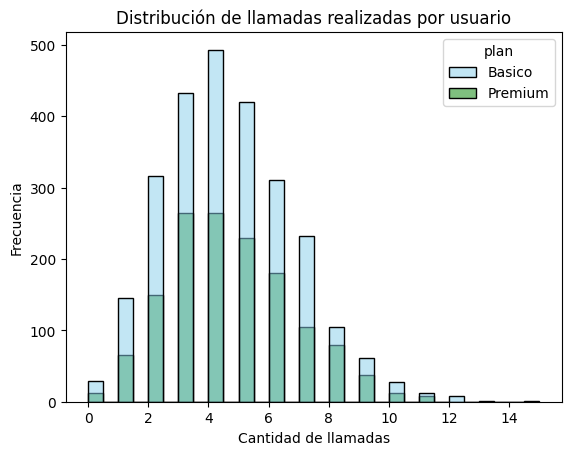

In [15]:
# Histograma para visualizar la cant_llamadas
sns.histplot(
    data=user_profile,
    x='cant_llamadas',
    hue='plan',
    bins=30,
    palette=['skyblue', 'green'],
    kde=False
)

plt.title('Distribución de llamadas realizadas por usuario')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')
plt.show()



💡Insights: 
- La distribución de llamadas es asimétrica y sesgada a la derecha: la mayoría de los usuarios realiza pocas llamadas.
- Existe un grupo reducido de usuarios con un número elevado de llamadas, lo que indica usuarios intensivos.
- Al comparar por tipo de plan, el plan Premium muestra una ligera mayor presencia en los valores altos de llamadas.
- En general, ambos planes presentan patrones similares, pero Premium concentra más consumo en la cola derecha.

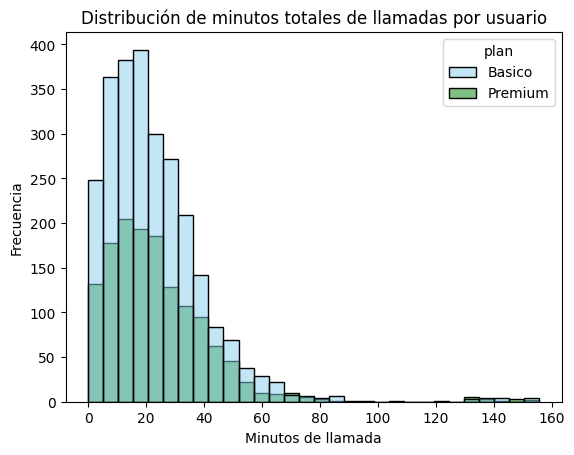

In [16]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    data=user_profile,
    x='cant_minutos_llamada',
    hue='plan',
    bins=30,
    palette=['skyblue', 'green'],
    kde=False
)

plt.title('Distribución de minutos totales de llamadas por usuario')
plt.xlabel('Minutos de llamada')
plt.ylabel('Frecuencia')
plt.show()


💡Insights: 
- La distribución de los minutos de llamada es fuertemente sesgada a la derecha, con una gran concentración de usuarios con bajo consumo y una cola larga de usuarios con consumo elevado.
- Se observan outliers claros de usuarios que acumulan muchos minutos de llamada, lo que sugiere la presencia de heavy callers.
- Al segmentar por tipo de plan, el plan Premium tiene mayor representación en los rangos altos de minutos consumidos.
- Este patrón indica una oportunidad para diseñar planes diferenciados o estrategias de upselling dirigidas a usuarios con alto consumo de llamadas.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

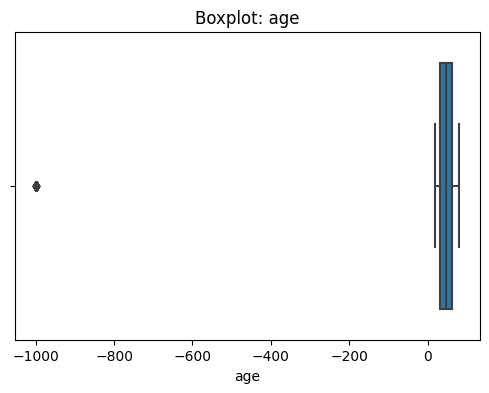

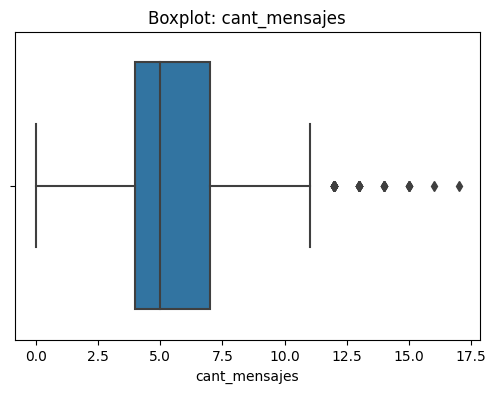

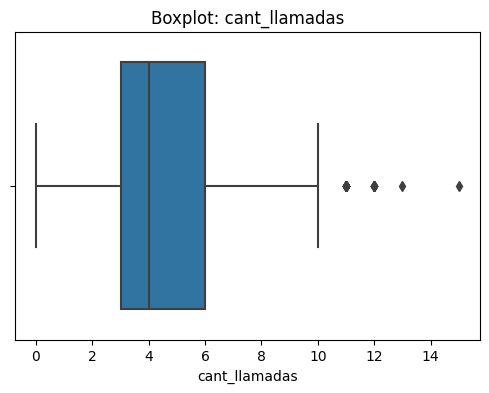

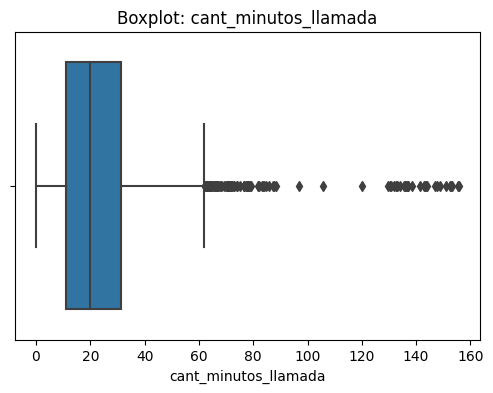

In [17]:

# Visualizando usando BoxPlot 

import matplotlib.pyplot as plt
import seaborn as sns

columnas_numericas = [
    'age',
    'cant_mensajes',
    'cant_llamadas',
    'cant_minutos_llamada'
]

for col in columnas_numericas:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=user_profile[col])
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights: 

- Age:
    No presenta outliers relevantes después de la limpieza. La distribución se mantiene dentro de rangos razonables para una población adulta.

- cant_mensajes:
    Presenta outliers claros en el extremo superior, correspondientes a usuarios con un volumen de mensajes significativamente mayor al promedio.

- cant_llamadas:
    Se observan outliers en la parte superior de la distribución, indicando usuarios con un número muy alto de llamadas.

- cant_minutos_llamada:
    Presenta outliers marcados en el extremo superior, representando usuarios con consumo intensivo de minutos de llamada.

In [18]:
# Calcular límites con el método IQR
columnas_limites = [
    'cant_mensajes',
    'cant_llamadas',
    'cant_minutos_llamada'
]

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 * IQR

    print(f'Columna: {col}')
    print(f'  Q1: {Q1}')
    print(f'  Q3: {Q3}')
    print(f'  IQR: {IQR}')
    print(f'  Límite superior (outliers): {limite_superior}')
    print('-' * 45)

Columna: cant_mensajes
  Q1: 4.0
  Q3: 7.0
  IQR: 3.0
  Límite superior (outliers): 11.5
---------------------------------------------
Columna: cant_llamadas
  Q1: 3.0
  Q3: 6.0
  IQR: 3.0
  Límite superior (outliers): 10.5
---------------------------------------------
Columna: cant_minutos_llamada
  Q1: 11.12
  Q3: 31.415
  IQR: 20.295
  Límite superior (outliers): 61.8575
---------------------------------------------


In [19]:

# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()


,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes:
    El valor máximo supera el límite superior calculado con IQR, confirmando la presencia de outliers. Sin embargo, estos valores representan usuarios con un uso intensivo de mensajería, lo cual es coherente con el comportamiento esperado del negocio.

- cant_llamadas:
    El máximo también se encuentra por encima del límite superior del IQR. Estos registros corresponden a usuarios que realizan un número muy elevado de llamadas, lo que sugiere un perfil de alto consumo y no un error de registro.

- cant_minutos_llamada:
      Se observan valores máximos considerablemente mayores al límite IQR, indicando usuarios con consumo extremo de minutos. Dado el contexto del servicio, estos valores son plausibles y representan heavy callers.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [20]:
# Crear columna grupo_uso
user_profile['grupo_uso'] = 'Alto uso'  # valor por defecto

cond_bajo = (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5)
cond_medio = (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10)

user_profile.loc[cond_bajo, 'grupo_uso'] = 'Bajo uso'
user_profile.loc[cond_medio & ~cond_bajo, 'grupo_uso'] = 'Uso medio'

In [22]:
# verificar cambios
user_profile[['user_id', 'cant_llamadas', 'cant_mensajes', 'grupo_uso']].head()

,user_id,cant_llamadas,cant_mensajes,grupo_uso
0,10000,3.0,7.0,Uso medio
1,10001,10.0,5.0,Alto uso
2,10002,2.0,5.0,Uso medio
3,10003,3.0,11.0,Alto uso
4,10004,3.0,4.0,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [23]:
# Crear columna grupo_edad
user_profile['grupo_edad'] = 'Adulto Mayor'  # valor por defecto

user_profile.loc[user_profile['age'] < 30, 'grupo_edad'] = 'Joven'
user_profile.loc[(user_profile['age'] >= 30) & (user_profile['age'] < 60), 'grupo_edad'] = 'Adulto'

In [24]:
# verificar cambios
user_profile[['user_id', 'age', 'grupo_edad']].head()

,user_id,age,grupo_edad
0,10000,38,Adulto
1,10001,53,Adulto
2,10002,57,Adulto
3,10003,69,Adulto Mayor
4,10004,63,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

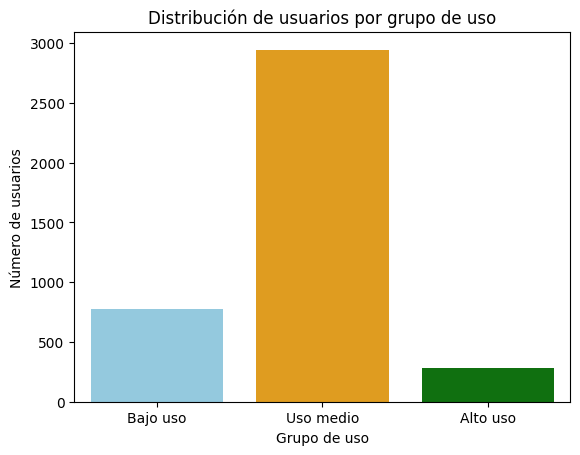

In [25]:
# Visualización de los segmentos por uso

sns.countplot(
    data=user_profile,
    x='grupo_uso',
    order=['Bajo uso', 'Uso medio', 'Alto uso'],
    palette=['skyblue', 'orange', 'green'])

plt.title('Distribución de usuarios por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Número de usuarios')
plt.show()

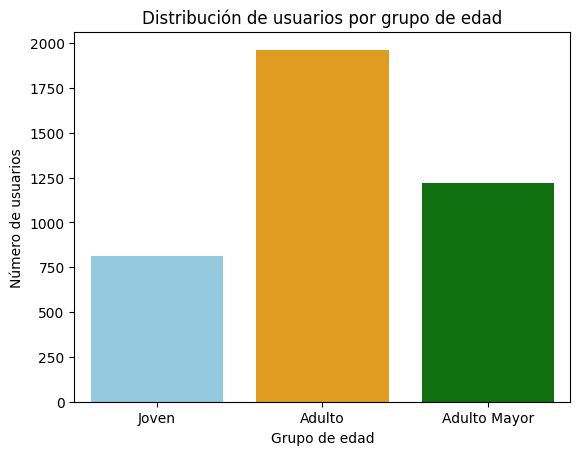

In [29]:
# Visualización de los segmentos por edad
sns.countplot(
    data=user_profile,
    x='grupo_edad',
    order=['Joven', 'Adulto', 'Adulto Mayor'],
    palette=['skyblue', 'orange', 'green'])

plt.title('Distribución de usuarios por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Número de usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
En la columna age se encontraron valores inválidos (-999), que representaban una pequeña parte del dataset. Estos valores se corrigieron usando la mediana.

En city se detectaron valores faltantes y registros con “?”, que indicaban información incompleta. Estos casos se estandarizaron como valores nulos.

En reg_date se identificaron 40 registros con fechas en 2026, fuera del rango esperado (datos hasta 2024), los cuales se marcaron como nulos.

En general, los problemas afectaban a pocos registros, pero era necesario corregirlos para asegurar la calidad del análisis.

🔍 **Segmentos por Edad**

Jóvenes: usan más mensajes y menos llamadas.

Adultos: muestran un uso equilibrado entre llamadas y mensajes y representan la mayoría de los clientes.

Adultos Mayores: usan principalmente llamadas y pocos mensajes.

La edad influye claramente en la forma en que los clientes usan el servicio.



📊 **Segmentos por Nivel de Uso**

Bajo uso: poco consumo de llamadas y mensajes.

Uso medio: consumo moderado, con potencial de crecimiento.

Alto uso: alto volumen de llamadas y mensajes, concentran gran parte del consumo.

➡️ Esto indica que no todos los clientes tienen el mismo valor para la empresa.


➡️ Esto sugiere que los clientes de ConnectaTel tienen comportamientos de uso muy distintos, por lo que una oferta de planes uniforme no cubre adecuadamente las necesidades de todos los segmentos.


💡 **Recomendaciones**

Crear planes especiales para usuarios de alto consumo.

Ofrecer planes enfocados en mensajería para usuarios jóvenes.

Aplicar estrategias de upselling para usuarios de uso medio.

Diseñar planes simples enfocados en llamadas para adultos mayores o usuarios de bajo uso.


---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`